# Assignment 4 : Student Performance Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 8)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [6]:
df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)/3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [7]:
df["Pass_Fail"] = df["average_score"].apply(
    lambda x: 1 if x >= 50 else 0
)

df[["average_score","Pass_Fail"]].head()

,average_score,Pass_Fail
0,72.666667,1
1,82.333333,1
2,92.666667,1
3,49.333333,0
4,76.333333,1


In [8]:
df["Pass_Fail"].value_counts()

,count
Pass_Fail,
1,897
0,103


In [9]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,math score,reading score,writing score,average_score,Pass_Fail,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,72.666667,1,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,82.333333,1,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,92.666667,1,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,49.333333,0,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,76.333333,1,True,False,True,False,False,False,False,False,True,False,True,True


In [10]:
X = df_encoded.drop(
    ["Pass_Fail","average_score"],
    axis=1
)

y = df_encoded["Pass_Fail"]

print(X.shape)
print(y.shape)

(1000, 15)
(1000,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 15)
(200, 15)


In [12]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

In [13]:
print("Accuracy:",
      accuracy_score(y_test,y_pred_lr))

print("Precision:",
      precision_score(y_test,y_pred_lr))

print("Recall:",
      recall_score(y_test,y_pred_lr))

print("F1 Score:",
      f1_score(y_test,y_pred_lr))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [14]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

In [15]:
print("Accuracy:",
      accuracy_score(y_test,y_pred_dt))

print("Precision:",
      precision_score(y_test,y_pred_dt))

print("Recall:",
      recall_score(y_test,y_pred_dt))

print("F1 Score:",
      f1_score(y_test,y_pred_dt))

Accuracy: 0.985
Precision: 0.9885057471264368
Recall: 0.9942196531791907
F1 Score: 0.9913544668587896


In [16]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

In [17]:
print("Accuracy:",
      accuracy_score(y_test,y_pred_rf))

print("Precision:",
      precision_score(y_test,y_pred_rf))

print("Recall:",
      recall_score(y_test,y_pred_rf))

print("F1 Score:",
      f1_score(y_test,y_pred_rf))

Accuracy: 0.995
Precision: 0.9942528735632183
Recall: 1.0
F1 Score: 0.9971181556195965


In [18]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf)
    ],
    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_dt),
        precision_score(y_test,y_pred_rf)
    ],
    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_rf)
    ],
    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.000,1.000000,1.00000,1.000000
1,Decision Tree,0.985,0.988506,0.99422,0.991354
2,Random Forest,0.995,0.994253,1.00000,0.997118


In [19]:
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print(scores)
print("Average Score:", scores.mean())

[0.98  0.975 0.985 0.99  1.   ]
Average Score: 0.986


In [20]:
param_grid = {
    "max_depth":[3,5,7,10],
    "min_samples_split":[2,5,10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5
)

grid_dt.fit(X_train,y_train)

print(grid_dt.best_params_)

{'max_depth': 10, 'min_samples_split': 2}


In [21]:
param_grid_rf = {
    "n_estimators":[50,100,200],
    "max_depth":[5,10,None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_grid_rf,
    cv=5
)

grid_rf.fit(X_train,y_train)

print(grid_rf.best_params_)

{'max_depth': None, 'n_estimators': 50}


In [22]:
train_sizes, train_scores, test_scores = learning_curve(
    rf,
    X,
    y,
    cv=5
)

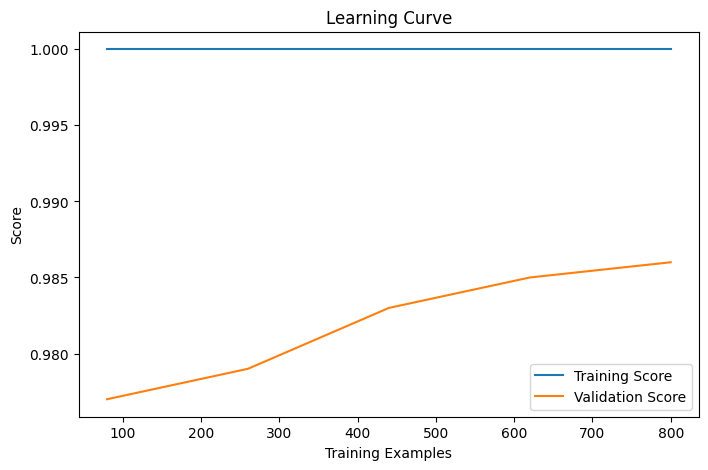

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    np.mean(train_scores,axis=1),
    label="Training Score"
)

plt.plot(
    train_sizes,
    np.mean(test_scores,axis=1),
    label="Validation Score"
)

plt.xlabel("Training Examples")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.legend()

plt.show()

Conclusion:

Logistic Regression achieved the highest performance with 100% accuracy, precision, recall, and F1-score, making it the best-performing model for this dataset.

Random Forest also performed exceptionally well with 99.5% accuracy, while Decision Tree achieved 98.5% accuracy.

The learning curve indicates strong generalization with minimal overfitting.

Therefore, Logistic Regression is the most suitable model for predicting student pass/fail outcomes in this dataset.